# MAD Factor Analysis
Median Absolute Deviation (MAD) method for winsorizing extreme values in factor data.

## Imports

In [1]:
from atrader import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas import DataFrame

## MAD Winsorization Function
Define the extreme value clipping function using the Median Absolute Deviation method.

In [2]:
def extreme_MAD(df: DataFrame, n=5.2) -> DataFrame:
    # get median
    median = df.median()
    # get median absolute deviation
    mad = abs(df - median).quantile(0.5)
    # upper and lower bound is not necessary to be symmetric
    df_up = median + n * mad
    df_down = median - n * mad
    return df.clip(lower=df_down, upper=df_up, axis=1)

## Fetch Factor Data
Retrieve HS300 stock codes and factor data (PE and PB ratios) for a given date.

In [3]:
date = '2025-07-01'
code_list = list(get_code_list('hs300', date=date).code)
print(code_list)

['szse.000001', 'szse.000002', 'szse.000063', 'szse.000100', 'szse.000157', 'szse.000166', 'szse.000301', 'szse.000333', 'szse.000338', 'szse.000408', 'szse.000425', 'szse.000538', 'szse.000568', 'szse.000596', 'szse.000617', 'szse.000625', 'szse.000630', 'szse.000651', 'szse.000661', 'szse.000708', 'szse.000725', 'szse.000768', 'szse.000776', 'szse.000786', 'szse.000792', 'szse.000800', 'szse.000807', 'szse.000858', 'szse.000876', 'szse.000895', 'szse.000938', 'szse.000963', 'szse.000975', 'szse.000977', 'szse.000983', 'szse.000999', 'szse.001289', 'szse.001965', 'szse.001979', 'szse.002001', 'szse.002007', 'szse.002027', 'szse.002028', 'szse.002049', 'szse.002050', 'szse.002074', 'szse.002129', 'szse.002142', 'szse.002179', 'szse.002180', 'szse.002230', 'szse.002236', 'szse.002241', 'szse.002252', 'szse.002271', 'szse.002304', 'szse.002311', 'szse.002352', 'szse.002371', 'szse.002415', 'szse.002422', 'szse.002459', 'szse.002460', 'szse.002463', 'szse.002466', 'szse.002475', 'szse.002

In [4]:
factor = get_factor_by_day(factor_list=['pe_ratio_ttm', 'pb_ratio_ttm'], target_list=code_list, date=date)
print(factor)

            code pe_ratio_ttm pb_ratio_ttm
0    SZSE.000001      5.46558      0.48385
1    SZSE.000002     -1.36843      0.34625
2    SZSE.000063     19.18826      2.17002
3    SZSE.000100     35.11959       1.5476
4    SZSE.000157     15.57477      1.09487
5    SZSE.000166     21.54159      1.20046
6    SZSE.000301    -25.51365       1.6412
7    SZSE.000333     13.17477      2.69576
8    SZSE.000338      11.6646      1.55017
9    SZSE.000408     24.45161       5.0054
10   SZSE.000425     14.36575      1.53638
11   SZSE.000538     19.97307      2.49564
12   SZSE.000568      12.2737       3.5848
13   SZSE.000596     12.03995      2.84882
14   SZSE.000617     21.73938      0.89228
15   SZSE.000625     16.80487      1.68907
16   SZSE.000630     15.31281      1.28492
17   SZSE.000651      7.61911      1.94075
18   SZSE.000661     18.56764      1.78582
19   SZSE.000708     11.50643      1.46721
20   SZSE.000725     25.07483       1.1302
21   SZSE.000768     73.74756      3.70997
22   SZSE.0

## Preprocess Factors
Set stock code as index and fill missing values.

In [5]:
factors = factor.set_index('code')
factors = factors.fillna(0)
factors.head()

,pe_ratio_ttm,pb_ratio_ttm
code,,
SZSE.000001,5.46558,0.48385
SZSE.000002,-1.36843,0.34625
SZSE.000063,19.18826,2.17002
SZSE.000100,35.11959,1.54760
SZSE.000157,15.57477,1.09487


## Visualize PE Ratio Distribution Before and After MAD Winsorization

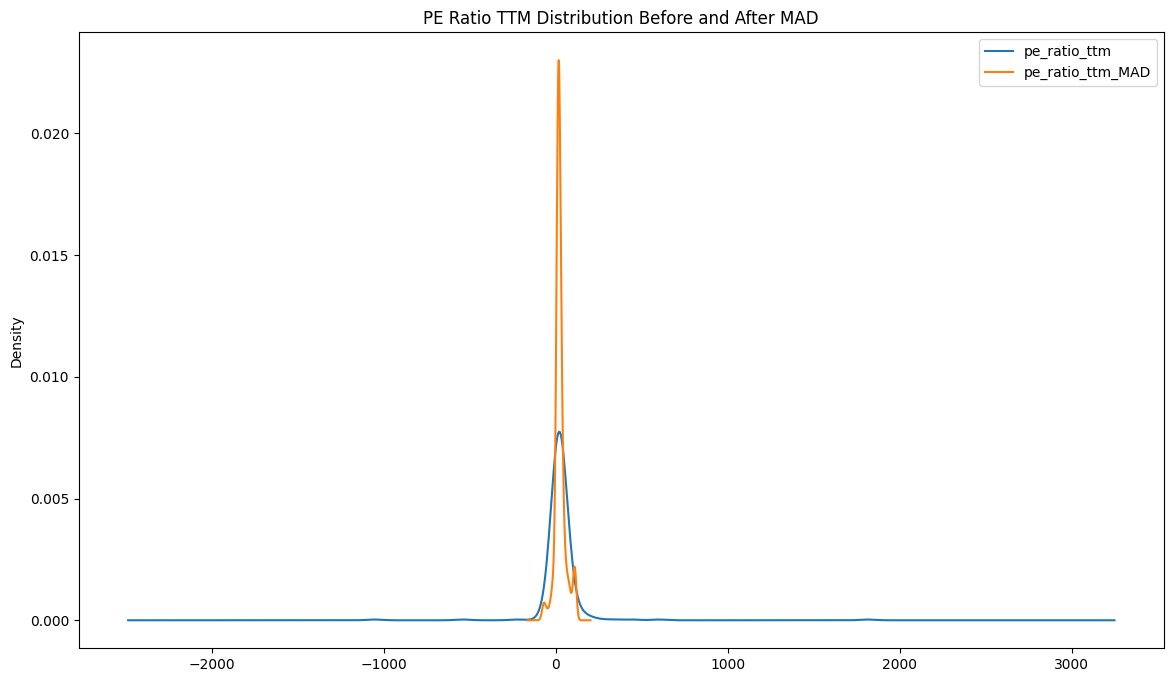

: 

In [ ]:
fig = plt.figure(figsize=(14, 8))
factors.iloc[:, 0].plot(kind='kde', label='pe_ratio_ttm')
extreme_MAD(factors, 10).iloc[:, 0].plot(kind='kde', label='pe_ratio_ttm_MAD')
plt.legend()
plt.title('PE Ratio TTM Distribution Before and After MAD')
plt.show()